# Experiment 2 — learning curves (LGD)

How R² scales with the amount of available data (no HPO; LinearRegression, TabICLv2, TabPFN-v3, and CatBoost). The swept `row_limit` caps the **dataset before the CV split** — train and test shrink together — so the x-axis is the **dataset size**, not the training-set size. Same structure as the PD notebook. Figures → `figures/experiment2/lgd/`.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import results_root
from src.methods.method_config import HPO_METHODS          # tuned methods -> HPO time x n_trials
from src.visualizations.experiment_plots import (
    apply_style, reset_figure_dir, load_summary,
    performance_heatmap, rank_heatmap, hpo_improvement_bars,
    compute_time_bars, runtime_performance_scatter,
    learning_curve, learning_curve_moving_average_with_dots,
    imbalance_curve, imbalance_curve_moving_average_with_dots, per_dataset_sweep_curves,
    sweep_evolution_summary, pd_summary_text, lgd_summary_text,
)
from src.utils.report import (notebook_report, capture, section,
                             preview)
apply_style()

RESULTS_ROOT = results_root()          # override here if your copy lives elsewhere
SUMMARY_DIR  = RESULTS_ROOT / 'summaries'
FIGURES_DIR  = reset_figure_dir(PROJECT_ROOT / 'figures' / 'experiment2/lgd')


In [2]:
df = load_summary(SUMMARY_DIR, experiment='experiment2', task='lgd', aggregated=False)
DISPLAY_METHODS = ['LinearRegression', 'tabicl_v2', 'tabpfn_v3', 'catboost']
missing = sorted(set(DISPLAY_METHODS) - set(df['method']))
if missing:
    preview(f'WARNING - no results for: {", ".join(missing)}')
df = df[df['method'].isin(DISPLAY_METHODS)].copy()


## 1. R? vs dataset size ? pooled over datasets

Views of the same curve (one line per method, mean over datasets):
1. **learning curve** with raw sweep points,
2. the same learning curve with a **lower-right inset** zooming the shaded `rows <= 1000` region,
3. **moving average** (trend),
4. **moving average with transparent raw points**.


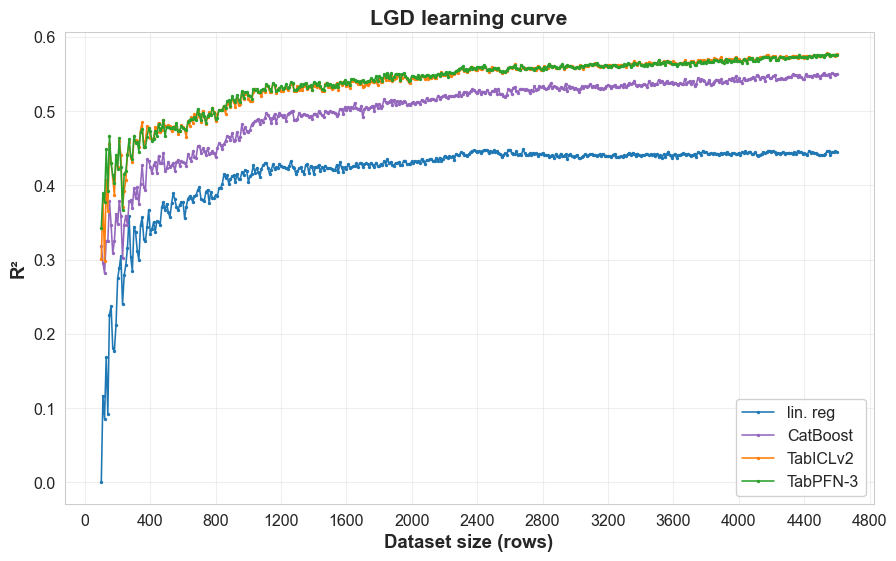

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_learning_curve_r2.pdf')

In [3]:
learning_curve(df, 'R2', task_name='LGD', out_dir=FIGURES_DIR)


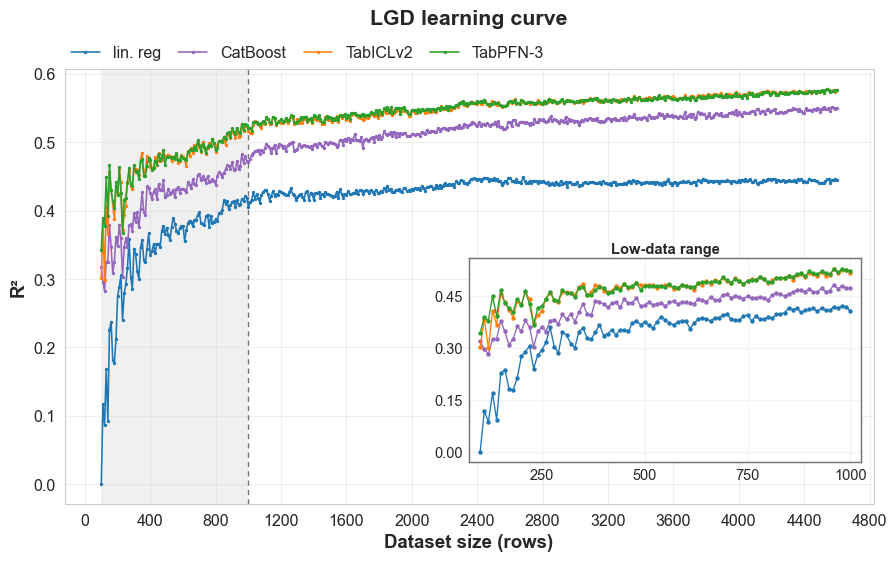

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_learning_curve_r2_zoom.pdf')

In [4]:
learning_curve(df, 'R2', task_name='LGD', zoom=True, out_dir=FIGURES_DIR)


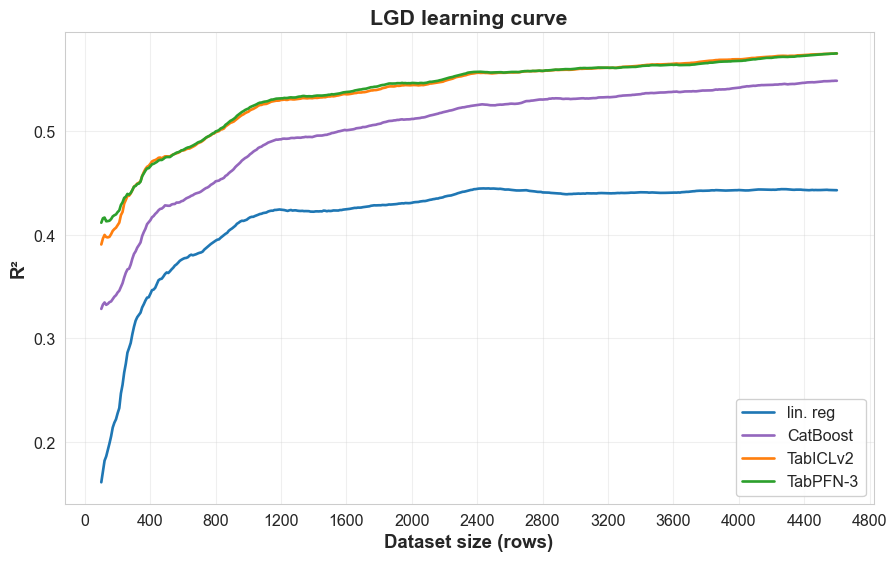

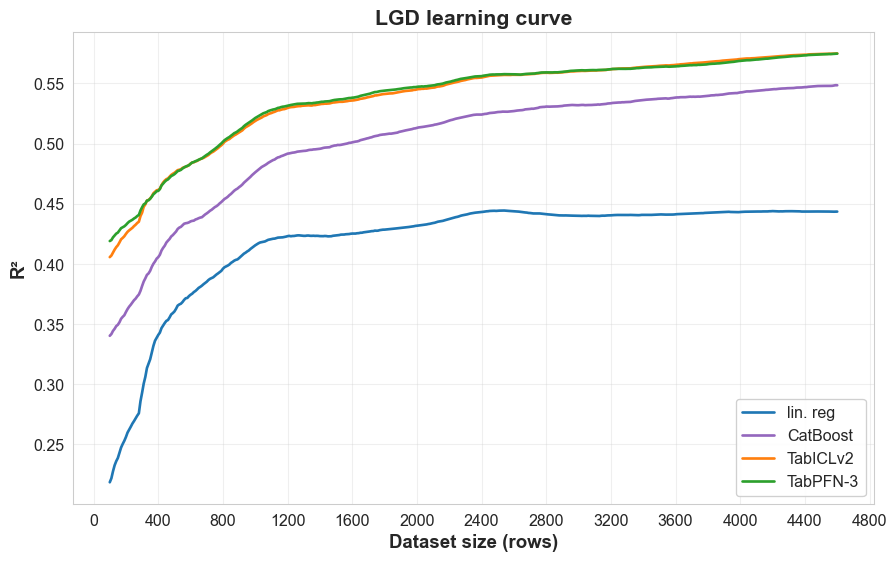

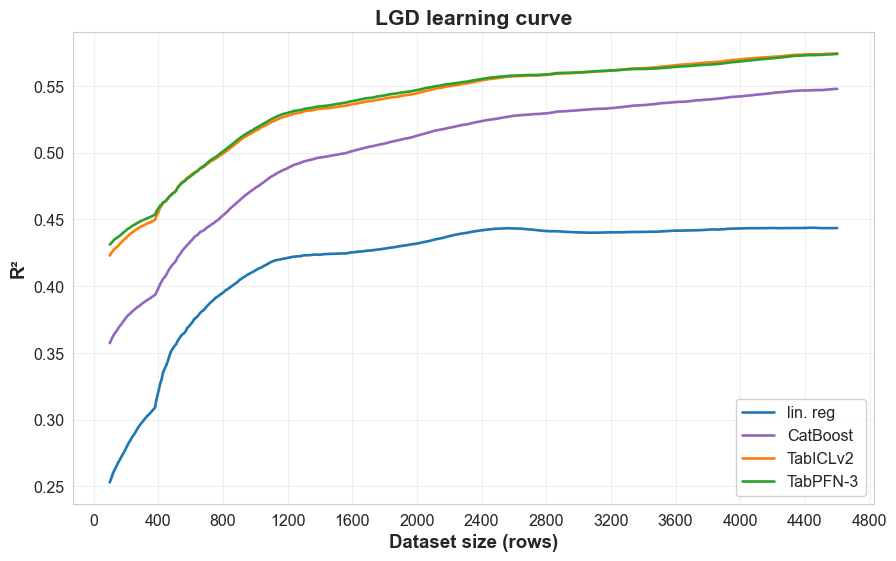

In [5]:
for smooth_window in ('less', 'standard', 'more'):
    learning_curve(df, 'R2', task_name='LGD', smooth=True, smooth_window=smooth_window, out_dir=FIGURES_DIR)


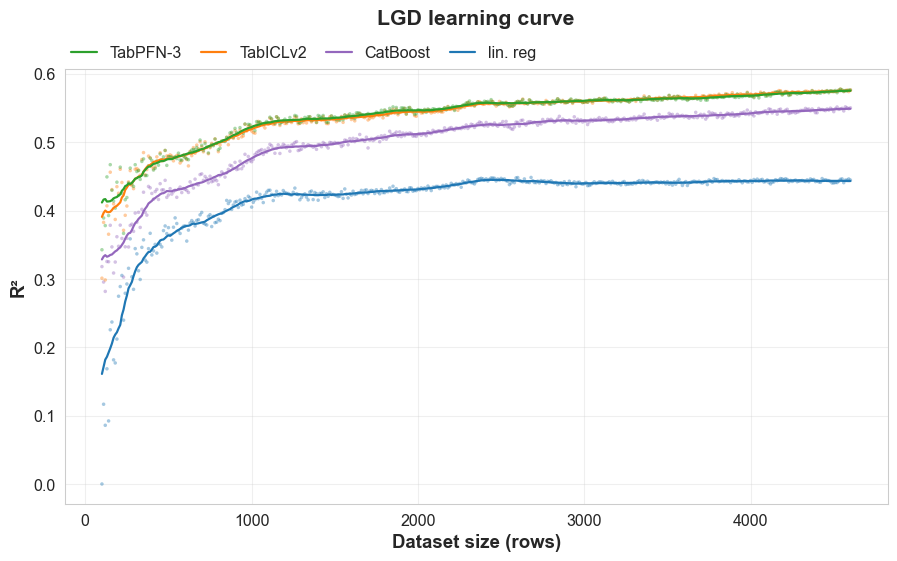

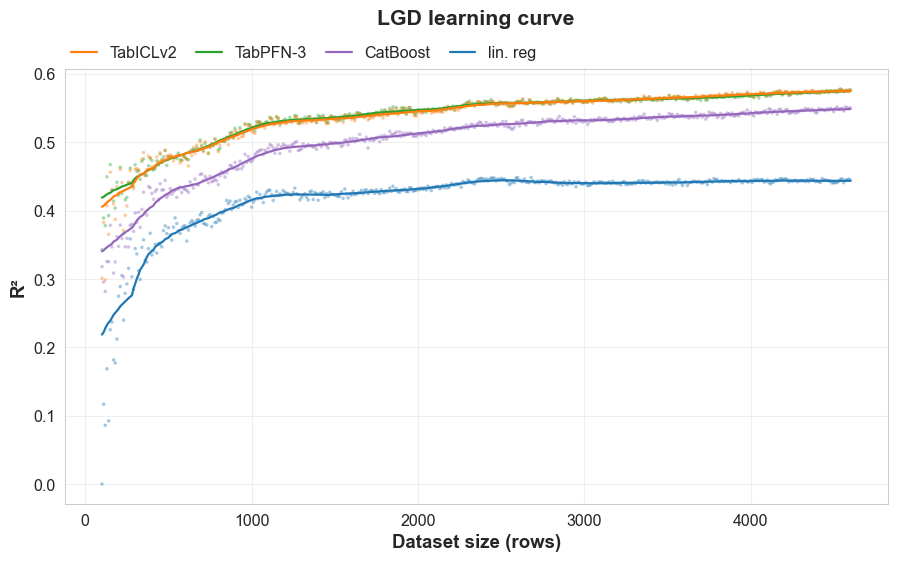

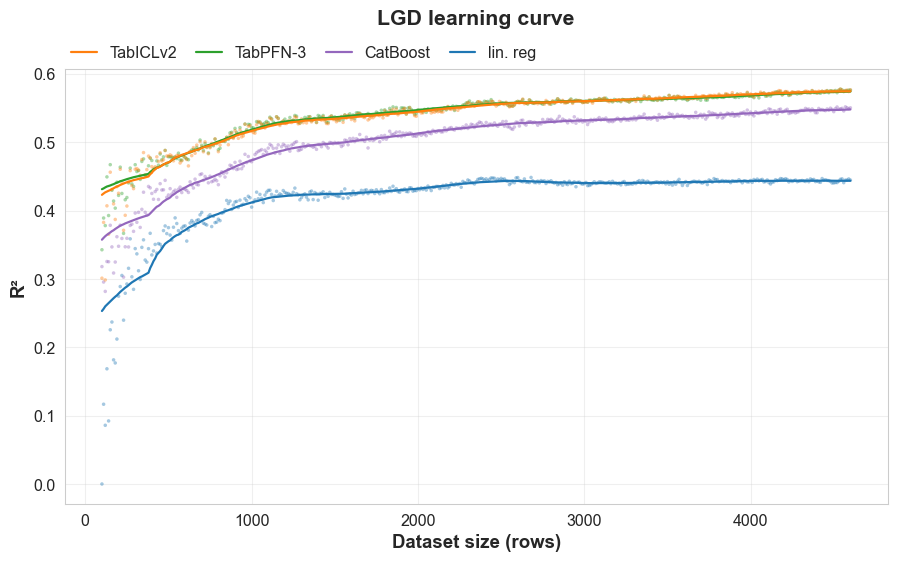

In [6]:
for smooth_window in ('less', 'standard', 'more'):
    learning_curve_moving_average_with_dots(df, 'R2', task_name='LGD', smooth_window=smooth_window, out_dir=FIGURES_DIR)


## 2. R² per dataset (raw points, all methods)

One plot per dataset so per-dataset behaviour is visible, not only the pooled mean.

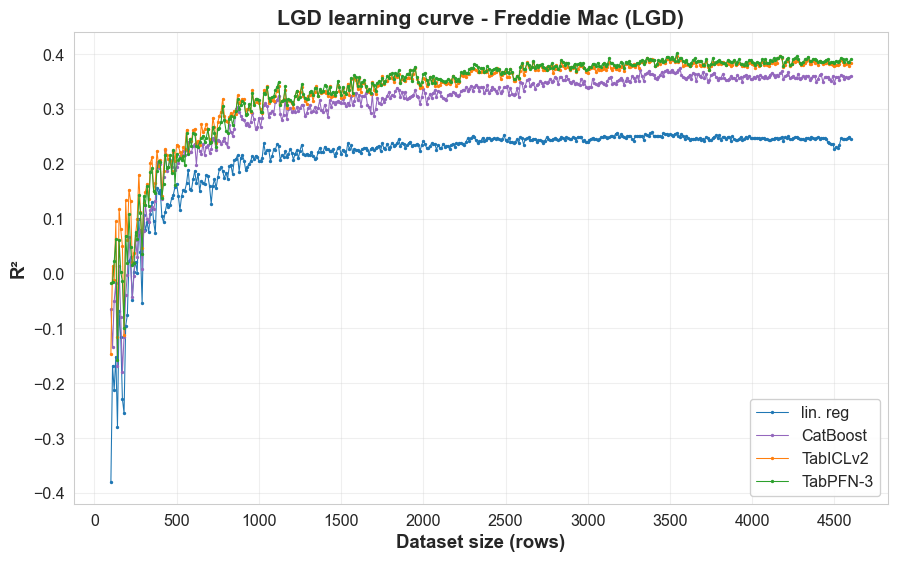

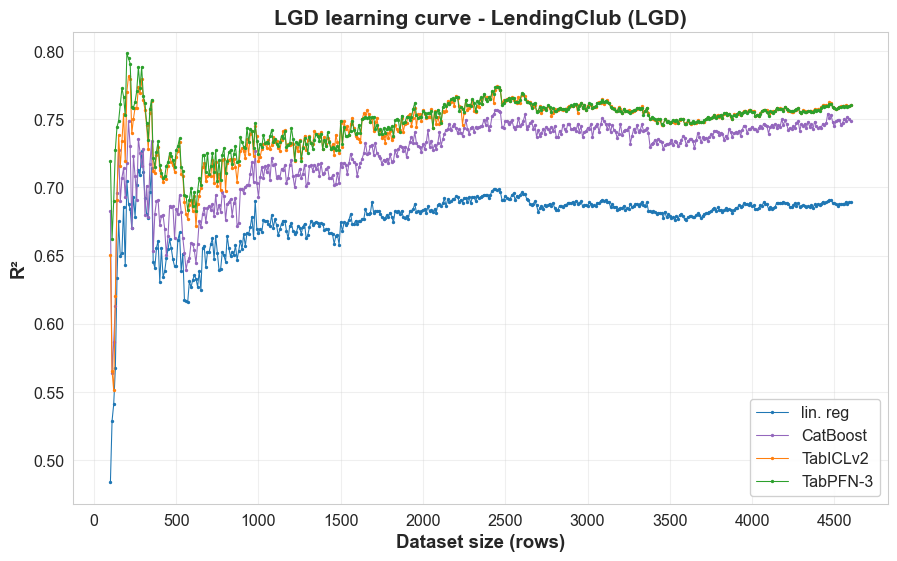

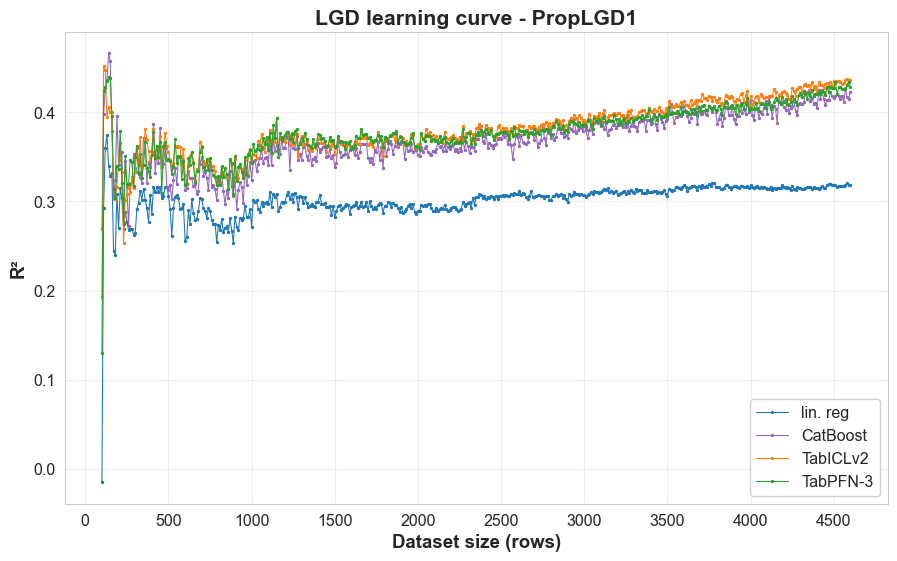

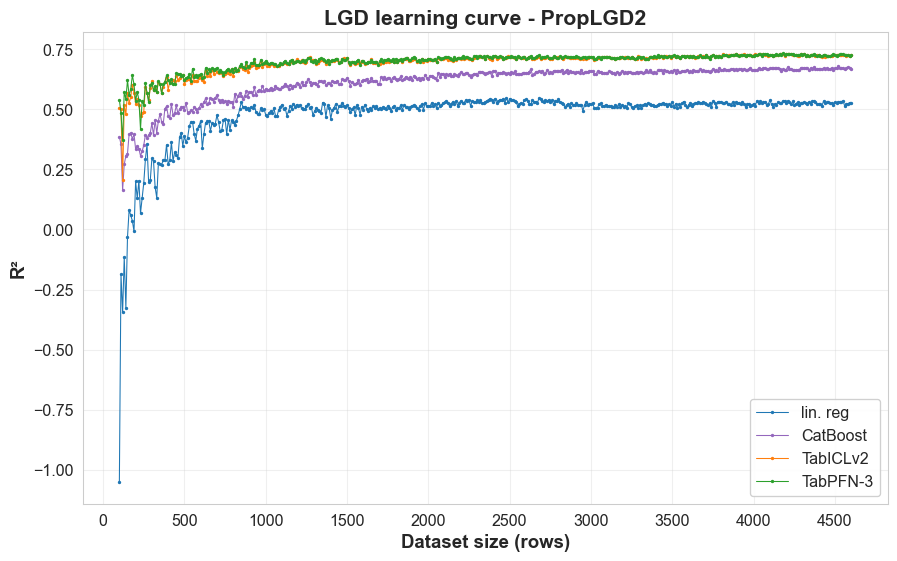

[WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_row_limit_0006_lgd_freddie_r2.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_row_limit_0007_lgd_lendingclub_r2.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_row_limit_proplgd1_r2.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_row_limit_0001_heloc_r2.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_row_limit_proplgd2_r2.pdf'),
 WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment2/lgd/lgd_row_limit_0002_loss2_r2.pdf')]

In [7]:
per_dataset_sweep_curves(df, 'R2', sweep_axis='row_limit', xlabel='Dataset size (rows)', task_name='LGD', out_dir=FIGURES_DIR)


## 3. Data efficiency — dataset rows to reach 95% of each method's own plateau

In [8]:
import pandas as _pd
g = df.groupby(['method','sweep_value'])['metric.R2'].mean().reset_index()
rows = {}
for m, gg in g.groupby('method'):
    gg = gg.sort_values('sweep_value'); target = gg['metric.R2'].max() * 0.95
    hit = gg[gg['metric.R2'] >= target]
    rows[m] = int(hit['sweep_value'].iloc[0]) if len(hit) else None
preview(_pd.Series(rows, name='rows to reach 95% of own max R2').sort_values(),
        label='Data efficiency')


**Data efficiency**

LinearRegression    1030
tabpfn_v3           1830
tabicl_v2           1920
catboost            2290
Name: rows to reach 95% of own max R2, dtype: int64

## Summary — the notebook's single printed report

Everything above, in text: this is the notebook's ONLY printed output, so `results/All_Results.md` is a complete text record of the analysis.

In [9]:
notebook_report(
    'Experiment 2 - LGD learning curves',
    notebook='Experiment2.2-LGD.ipynb',
    about=('Learning-curve sweep on LGD: R2 versus training-set size (row_limit caps the rows before the CV split), pooled and per dataset.'),
    sections=[
        section('Sweep coverage',
                f'{df["method"].nunique()} methods x {df["dataset"].nunique()} datasets, '
                f'{df["sweep_value"].nunique()} sweep points'),
        section('Data efficiency: rows needed to reach 95% of a method\'s own best R2',
                _pd.Series(rows, name='rows to reach 95% of own max R2').sort_values()),
        section('R2 evolution across the whole sweep',
                capture(sweep_evolution_summary, df, 'R2', sweep_axis='row_limit',
                        task_name='Experiment 2 - LGD')),
    ],
)

EXPERIMENT 2 - LGD LEARNING CURVES -- COMPLETE TEXT SUMMARY
Source notebook : notebooks/Experiment2.2-LGD.ipynb
Contents        : Learning-curve sweep on LGD: R2 versus training-set size (row_limit caps the rows before the CV split), pooled and per dataset.
Sections        : 3

This is the notebook's ONLY printed output: every table and figure-backing
number it produces is reproduced below, so results/All_Results.md is a
complete text record of the analysis.

------------------------------------------------------------------------------
[1] Sweep coverage
------------------------------------------------------------------------------
4 methods x 4 datasets, 451 sweep points

------------------------------------------------------------------------------
[2] Data efficiency: rows needed to reach 95% of a method's own best R2
------------------------------------------------------------------------------
LinearRegression    1030
tabpfn_v3           1830
tabicl_v2           1920
catboost    

"==============================================================================\nEXPERIMENT 2 - LGD LEARNING CURVES -- COMPLETE TEXT SUMMARY\n==============================================================================\nSource notebook : notebooks/Experiment2.2-LGD.ipynb\nContents        : Learning-curve sweep on LGD: R2 versus training-set size (row_limit caps the rows before the CV split), pooled and per dataset.\nSections        : 3\n\nThis is the notebook's ONLY printed output: every table and figure-backing\nnumber it produces is reproduced below, so results/All_Results.md is a\ncomplete text record of the analysis.\n\n------------------------------------------------------------------------------\n[1] Sweep coverage\n------------------------------------------------------------------------------\n4 methods x 4 datasets, 451 sweep points\n\n------------------------------------------------------------------------------\n[2] Data efficiency: rows needed to reach 95% of a method's ow